In [1]:
# load master CSVs
import pandas as pd
df1 = pd.read_csv("/Users/elenadickens/Desktop/ASTR_502/ASTR502_Master_Target_List.csv")
print(df1.head())
print(df1.info())

      pl_name  hostname        ra        dec  sy_vmag  sy_jmag  sy_kmag  \
0  HIP 65 A b  HIP 65 A  0.185606 -54.830823   11.000    8.922    8.290   
1  WASP-136 b  WASP-136  0.325761  -8.926251    9.974    9.016    8.805   
2    KELT-1 b    KELT-1  0.362100  39.383795   10.632    9.682    9.437   
3   HATS-34 b   HATS-34  0.774487 -62.469317   13.857   12.513   12.095   
4   WASP-96 b   WASP-96  1.046570 -47.360635   12.569   11.267   10.914   

   st_teff  st_logg  st_met  st_age  st_ageerr1  st_ageerr2  pl_orbper  \
0   4590.0    4.611   0.180    4.10         4.3        -2.8   0.980973   
1   6250.0    3.900  -0.180    3.62         0.7        -0.7   5.215362   
2   6516.0    4.228   0.052     NaN         NaN         NaN   1.217514   
3   5380.0    4.435   0.250    7.70         2.7        -2.7   2.106161   
4   5540.0    4.420   0.140    8.00        26.0        -8.0   3.425260   

     pl_rade  pl_trandur                                 disc_facility  \
0  22.754270    0.785760  Tran

In [2]:
df2 = pd.read_csv("/Users/elenadickens/Desktop/ASTR_502/ASTR502_Master_Photometry_List.csv")
print(df2.head())
print(df2.info())

      pl_name  hostname          gaia_dr3_id   gaia_dr2_id     tic_id  \
0  HIP 65 A b  HIP 65 A  4923860051276772608  4.923860e+18  201248411   
1  WASP-136 b  WASP-136  2441013811932929280  2.441014e+18  176220787   
2    KELT-1 b    KELT-1  2881784280929695360  2.881784e+18  432549364   
3   HATS-34 b   HATS-34  4904523077718046720  4.904523e+18  355703913   
4   WASP-96 b   WASP-96  4990044668377961984  4.990045e+18  160148385   

         ra        dec   FUVmag  e_FUVmag   NUVmag  ...  tic_e_Bmag  tic_Vmag  \
0  0.185606 -54.830823      NaN       NaN  19.2287  ...       0.024    11.000   
1  0.325761  -8.926251  19.6423    0.1755  14.0747  ...       0.050     9.974   
2  0.362100  39.383795      NaN       NaN      NaN  ...       0.110    10.632   
3  0.774487 -62.469317      NaN       NaN  20.0753  ...       0.045    13.857   
4  1.046570 -47.360635      NaN       NaN  18.6931  ...       0.016    12.569   

   tic_e_Vmag   gaiamag  e_gaiamag  gaia_Gmag  gaia_BPmag  gaia_RPmag  \
0

In [3]:
df1_clean = df1.drop_duplicates(subset="hostname")
df2_clean = df2.drop_duplicates(subset="hostname")
merged = pd.merge(df1_clean, df2_clean, on="hostname", how="inner")
print(len(df1_clean), len(df2_clean), len(merged))

3425 3367 3365


In [4]:
merged["ra"] = merged["ra_x"]
merged["dec"] = merged["dec_x"]

merged = merged.drop(columns=[
    "ra_x", "ra_y", "dec_x", "dec_y",
    "pl_name_y"
])

In [5]:
print(merged["hostname"].nunique(), len(merged))

3365 3365


In [6]:
print(merged.head())
print(merged.columns)

    pl_name_x  hostname  sy_vmag  sy_jmag  sy_kmag  st_teff  st_logg  st_met  \
0  HIP 65 A b  HIP 65 A   11.000    8.922    8.290   4590.0    4.611   0.180   
1  WASP-136 b  WASP-136    9.974    9.016    8.805   6250.0    3.900  -0.180   
2    KELT-1 b    KELT-1   10.632    9.682    9.437   6516.0    4.228   0.052   
3   HATS-34 b   HATS-34   13.857   12.513   12.095   5380.0    4.435   0.250   
4   WASP-96 b   WASP-96   12.569   11.267   10.914   5540.0    4.420   0.140   

   st_age  st_ageerr1  ...  tic_e_Vmag   gaiamag  e_gaiamag  gaia_Gmag  \
0    4.10         4.3  ...       0.030  10.58950   0.000446  10.588468   
1    3.62         0.7  ...       0.003   9.81929   0.000208   9.823880   
2     NaN         NaN  ...       0.007  10.59050   0.000342  10.592974   
3    7.70         2.7  ...       0.137  13.67900   0.000279  13.666666   
4    8.00        26.0  ...       0.069  12.38330   0.000260  12.372176   

  gaia_BPmag  gaia_RPmag     Tmag  e_Tmag        ra        dec  
0  11.212

In [7]:
# keep only the columns the model needs
cols = [
    "hostname",

    # photometry (core)
    "gaia_Gmag", "gaia_BPmag", "gaia_RPmag",
    "Jmag", "Hmag", "Kmag",

    # errors
    "e_Jmag", "e_Hmag", "e_Kmag",

    # priors
    "st_teff", "st_age", "st_met",

    # optional metadata
    "ra", "dec"
]

merged = merged[cols]
print(merged.head())
print(merged.columns)

   hostname  gaia_Gmag  gaia_BPmag  gaia_RPmag    Jmag    Hmag    Kmag  \
0  HIP 65 A  10.588468   11.212916    9.835994   8.922   8.400   8.290   
1  WASP-136   9.823880   10.060003    9.431094   9.016   8.792   8.805   
2    KELT-1  10.592974   10.857854   10.164225   9.682   9.534   9.437   
3   HATS-34  13.666666   14.053605   13.118170  12.513  12.139  12.095   
4   WASP-96  12.372176   12.735786   11.849231  11.267  10.936  10.914   

   e_Jmag  e_Hmag  e_Kmag  st_teff  st_age  st_met        ra        dec  
0   0.019   0.031   0.025   4590.0    4.10   0.180  0.185606 -54.830823  
1   0.030   0.026   0.024   6250.0    3.62  -0.180  0.325761  -8.926251  
2   0.022   0.030   0.019   6516.0     NaN   0.052  0.362100  39.383795  
3   0.024   0.022   0.019   5380.0    7.70   0.250  0.774487 -62.469317  
4   0.025   0.023   0.024   5540.0    8.00   0.140  1.046570 -47.360635  
Index(['hostname', 'gaia_Gmag', 'gaia_BPmag', 'gaia_RPmag', 'Jmag', 'Hmag',
       'Kmag', 'e_Jmag', 'e_Hmag', 

In [8]:
merged = merged.dropna(subset=[
    "gaia_Gmag", "gaia_BPmag", "gaia_RPmag",
    "Jmag", "Hmag", "Kmag",
    "st_teff"
])

merged["st_met"] = merged["st_met"].fillna(0.0)

In [9]:
print(len(merged))
print(merged.isna().sum())
print(merged["hostname"].nunique(), len(merged))

3357
hostname        0
gaia_Gmag       0
gaia_BPmag      0
gaia_RPmag      0
Jmag            0
Hmag            0
Kmag            0
e_Jmag         14
e_Hmag         12
e_Kmag         25
st_teff         0
st_age        516
st_met          0
ra              0
dec             0
dtype: int64
3357 3357


In [10]:
merged["e_Jmag"].fillna(0.03, inplace=True)
merged["e_Hmag"].fillna(0.03, inplace=True)
merged["e_Kmag"].fillna(0.03, inplace=True)

In [11]:
from IPython.display import display, HTML

display(HTML(merged.to_html(max_rows=50)))

,hostname,gaia_Gmag,gaia_BPmag,gaia_RPmag,Jmag,Hmag,Kmag,e_Jmag,e_Hmag,e_Kmag,st_teff,st_age,st_met,ra,dec
0,HIP 65 A,10.588468,11.212916,9.835994,8.922,8.400,8.290,0.019,0.031,0.025,4590.0,4.100,0.180,0.185606,-54.830823
1,WASP-136,9.823880,10.060003,9.431094,9.016,8.792,8.805,0.030,0.026,0.024,6250.0,3.620,-0.180,0.325761,-8.926251
2,KELT-1,10.592974,10.857854,10.164225,9.682,9.534,9.437,0.022,0.030,0.019,6516.0,NaN,0.052,0.362100,39.383795
3,HATS-34,13.666666,14.053605,13.118170,12.513,12.139,12.095,0.024,0.022,0.019,5380.0,7.700,0.250,0.774487,-62.469317
4,WASP-96,12.372176,12.735786,11.849231,11.267,10.936,10.914,0.025,0.023,0.024,5540.0,8.000,0.140,1.046570,-47.360635
5,TOI-198,10.915721,11.910542,9.930160,8.655,8.143,7.856,0.024,0.026,0.021,3650.0,5.300,-0.700,2.271509,-27.121745
6,WASP-44,12.883635,13.273107,12.335880,11.702,11.408,11.341,0.023,0.025,0.026,5420.0,10.300,-0.003,3.903273,-11.938265
7,Gliese 12,11.399355,12.830511,10.227193,8.619,8.068,7.807,0.020,0.026,0.020,3296.0,7.000,-0.320,3.957914,13.557617
8,WASP-32,11.409403,11.692119,10.963176,10.503,10.248,10.161,0.022,0.028,0.023,6140.0,2.220,-0.130,3.961707,1.200512
9,WASP-158,12.081388,12.360909,11.643996,11.178,10.957,10.881,0.026,0.023,0.025,6350.0,1.930,0.240,4.146347,-10.976423


In [12]:
from astroquery.gaia import Gaia

Some IP addresses of users launching heavy query showers have temporarily been disabled. Please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk) for advice. Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [13]:
def get_distance_pc(ra, dec, radius=2/3600):
    """
    Query Gaia for parallax near RA/Dec.
    Returns distance in parsecs.
    """
    
    query = f"""
    SELECT TOP 1 parallax
    FROM gaiadr3.gaia_source
    WHERE CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra}, {dec}, {radius})
    ) = 1
    """
    
    job = Gaia.launch_job(query)
    result = job.get_results()
    
    if len(result) == 0 or result['parallax'][0] <= 0:
        return np.nan
    
    parallax_mas = result['parallax'][0]
    distance_pc = 1000.0 / parallax_mas
    
    return distance_pc

In [14]:
# convert a dataframe row into a dict with all info needed for the pipeline
def row_to_star(row):
    star = {
        "hostname": row["hostname"],
        "photometry": {
            "G": row["gaia_Gmag"],
            "BP": row["gaia_BPmag"],
            "RP": row["gaia_RPmag"],
            "J": row["Jmag"],
            "H": row["Hmag"],
            "K": row["Kmag"],
        },
        "phot_err": {
            "J": row["e_Jmag"],
            "H": row["e_Hmag"],
            "K": row["e_Kmag"],
        },
        "teff": row["st_teff"],
        "feh": row["st_met"],
        "age_true": row.get("st_age", None)  # for validation only
    }
    return star

test_star = row_to_star(merged.iloc[0])
print(test_star)

{'hostname': 'HIP 65 A', 'photometry': {'G': 10.5884675979614, 'BP': 11.2129163742065, 'RP': 9.83599376678467, 'J': 8.922, 'H': 8.4, 'K': 8.29}, 'phot_err': {'J': 0.019, 'H': 0.031, 'K': 0.025}, 'teff': 4590.0, 'feh': 0.18, 'age_true': 4.1}


In [15]:
def fit_star(star):
    """
    Placeholder for isochrone fitting function.
    Currently returns dummy results.
    """
    # Later replace with actual likelihood/interpolator call
    return {
        "hostname": star["hostname"],
        "age_fit": 5.0,  # dummy age
        "mass_fit": 1.0,  # dummy mass
    }

fit_star(test_star)

{'hostname': 'HIP 65 A', 'age_fit': 5.0, 'mass_fit': 1.0}

In [16]:
results = []

# test first 5 stars
for _, row in merged.iloc[:5].iterrows():
    star = row_to_star(row)
    result = fit_star(star)
    results.append(result)

# convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

   hostname  age_fit  mass_fit
0  HIP 65 A      5.0       1.0
1  WASP-136      5.0       1.0
2    KELT-1      5.0       1.0
3   HATS-34      5.0       1.0
4   WASP-96      5.0       1.0


In [17]:
batch_size = 100  # start small
for i in range(0, len(merged), batch_size):
    batch = merged.iloc[i:i+batch_size]
    batch_results = []
    for _, row in batch.iterrows():
        star = row_to_star(row)
        batch_results.append(fit_star(star))
    
    # append to main results
    results_df = pd.concat([results_df, pd.DataFrame(batch_results)], ignore_index=True)

print(results_df)

      hostname  age_fit  mass_fit
0     HIP 65 A      5.0       1.0
1     WASP-136      5.0       1.0
2       KELT-1      5.0       1.0
3      HATS-34      5.0       1.0
4      WASP-96      5.0       1.0
...        ...      ...       ...
3357   Qatar-3      5.0       1.0
3358  WASP-147      5.0       1.0
3359    WASP-5      5.0       1.0
3360  TOI-3629      5.0       1.0
3361    WASP-8      5.0       1.0

[3362 rows x 3 columns]


In [18]:
# start small with ~100 young stars to test the pipeline
# drop rows with missing age 
young_stars = merged.dropna(subset=['st_age'])

# define young stars
young_stars = young_stars[young_stars['st_age'] < 2.0]  

# sample ~100 stars
young_sample = young_stars.sample(n=100, random_state=42)

# add distance
young_sample['distance_pc'] = young_sample.apply(
    lambda row: get_distance_pc(row['ra'], row['dec']),
    axis=1
)

young_sample.head()

,hostname,gaia_Gmag,gaia_BPmag,gaia_RPmag,Jmag,Hmag,Kmag,e_Jmag,e_Hmag,e_Kmag,st_teff,st_age,st_met,ra,dec,distance_pc
3125,HD 235088,8.953323,9.406647,8.334923,7.646,7.224,7.084,0.037,0.034,0.016,5075.0,0.70,-0.02,300.615454,53.377442,41.244624
2943,Kepler-99,12.949096,13.523342,12.236009,11.368,10.852,10.757,0.020,0.022,0.018,4782.0,1.47,0.18,297.353999,41.300045,208.271613
3117,Kepler-1518,13.268091,13.564443,12.806633,12.309,12.101,12.058,0.021,0.024,0.023,6846.0,1.48,0.06,300.332340,44.986106,944.823787
2857,Kepler-1722,14.846444,15.295652,14.234133,13.450,13.124,13.078,0.032,0.044,0.038,5506.0,1.40,-0.20,296.662740,41.261198,771.390194
2490,Kepler-642,13.281812,13.553617,12.853696,12.363,12.152,12.095,0.021,0.018,0.020,6570.0,1.95,0.06,293.834554,42.624948,777.834742


In [19]:
def apparent_to_absolute(m, d):
    return m - 5*np.log10(d) + 5

def row_to_star(row):

    d = row['distance_pc']

    photometry = {
        'G': apparent_to_absolute(row['gaia_Gmag'], d),
        'BP': apparent_to_absolute(row['gaia_BPmag'], d),
        'RP': apparent_to_absolute(row['gaia_RPmag'], d),
        'J': apparent_to_absolute(row['Jmag'], d),
        'H': apparent_to_absolute(row['Hmag'], d),
        'K': apparent_to_absolute(row['Kmag'], d),
    }

    phot_err = {
        'J': row['e_Jmag'],
        'H': row['e_Hmag'],
        'K': row['e_Kmag']
    }

    return {
        'hostname': row['hostname'],
        'photometry': photometry,
        'phot_err': phot_err,
        'teff': row['st_teff'],
        'feh': row['st_met'],
        'age_true': row['st_age']
    }

In [20]:
import numpy as np
young_star_dicts = [row_to_star(row) for _, row in young_sample.iterrows()]
print(young_star_dicts)

[{'hostname': 'HD 235088', 'photometry': {'G': 5.8764866221121626, 'BP': 6.329809986369982, 'RP': 5.258086048381692, 'J': 4.569163257854352, 'H': 4.147163257854352, 'K': 4.0071632578543515}, 'phot_err': {'J': 0.037, 'H': 0.034, 'K': 0.016}, 'teff': 5075.0, 'feh': -0.02, 'age_true': 0.7}, {'hostname': 'Kepler-99', 'photometry': {'G': 6.355945319217257, 'BP': 6.930191725772458, 'RP': 5.642858237308058, 'J': 4.774849593204058, 'H': 4.258849593204058, 'K': 4.163849593204057}, 'phot_err': {'J': 0.02, 'H': 0.022, 'K': 0.018}, 'teff': 4782.0, 'feh': 0.18, 'age_true': 1.47}, {'hostname': 'Kepler-1518', 'photometry': {'G': 3.3913371083913066, 'BP': 3.6876885411916067, 'RP': 2.9298789022146075, 'J': 2.432245906609106, 'H': 2.2242459066091076, 'K': 2.1812459066091066}, 'phot_err': {'J': 0.021, 'H': 0.024, 'K': 0.023}, 'teff': 6846.0, 'feh': 0.06, 'age_true': 1.48}, {'hostname': 'Kepler-1722', 'photometry': {'G': 5.410073560104253, 'BP': 5.859281819686853, 'RP': 4.7977621968840545, 'J': 4.01362943

In [21]:
feh_min = merged['st_met'].min()
feh_max = merged['st_met'].max()
st_age_min = merged['st_age'].min()
st_age_max = merged['st_age'].max()

print(f"Min [Fe/H]: {feh_min:.2f}, Max [Fe/H]: {feh_max:.2f}")
print(f'Min Age: {st_age_min:.2f}, Max Age: {st_age_max:.2f}')

Min [Fe/H]: -0.95, Max [Fe/H]: 0.56
Min Age: 0.00, Max Age: 16.10


In [26]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from isochrones.mist import MIST_Isochrone
from scipy.interpolate import RegularGridInterpolator

mist = MIST_Isochrone()

age_grid  = np.linspace(6.0, 10.2, 60)     # log(age/yr) from 1 Myr → 16 Gyr
feh_grid  = np.linspace(-2.5, 0.5, 31)     # halo → super-solar
mass_grid = np.linspace(0.1, 10.0, 200)    # M dwarfs → massive MS

interpolator_bands = ['J_mag', 'H_mag', 'K_mag', 'G_mag', 'BP_mag', 'RP_mag']
shape = (len(age_grid), len(feh_grid), len(mass_grid))
cubes = {band: np.full(shape, np.nan) for band in interpolator_bands}

for i, age in enumerate(age_grid):
    for j, feh in enumerate(feh_grid):
        iso = mist.isochrone(age, feh)
        if iso.empty:
            continue
        iso = iso.sort_values('initial_mass')
        for band in interpolator_bands:
            cubes[band][i, j, :] = np.interp(
                mass_grid,
                iso['initial_mass'],
                iso[band],
                left=np.nan,
                right=np.nan
            )

interpolators = {}
for band in interpolator_bands:
    interpolators[band] = RegularGridInterpolator(
        (age_grid, feh_grid, mass_grid),
        cubes[band],
        bounds_error=False,
        fill_value=np.nan
    )

# bands we will use
bands = ["G_mag", "BP_mag", "RP_mag", "J_mag", "H_mag", "K_mag"]

# Define which bands to fit and mapping to interpolator bands
fit_bands = ["G", "BP", "RP", "J", "H", "K"]
band_map = {b: b + "_mag" for b in fit_bands}  # maps G -> G_mag etc.

def chi2_model(params, star):

    logage, mass = params
    feh = np.clip(star['feh'], feh_grid.min(), feh_grid.max())
    y = np.array([star['photometry'][b] for b in fit_bands])
    yerr = np.array([star['phot_err'].get(b,0.02) for b in fit_bands])
    model_mags = np.array([
        interpolators[band_map[b]]([[logage, feh, mass]])[0]
        for b in fit_bands
    ])
    if np.any(np.isnan(model_mags)):
        return 1e10
    chi2 = np.sum(((y - model_mags)/yerr)**2)

    return chi2

def fit_star(star):

    initial_guess = [7.5,1.0]
    bounds = [
        (6.0,10.2),
        (0.1,10.0)
    ]
    result = minimize(
        chi2_model,
        initial_guess,
        args=(star,),
        bounds=bounds,
        method='L-BFGS-B'
    )
    best_logage, best_mass = result.x

    return {
    'hostname': star['hostname'],

    # fitted parameters
    'age_fit': 10**best_logage / 1e9,   # Gyr
    'mass_fit': best_mass,

    # catalog parameters
    'age_catalog': star['age_true'],
    'feh': star['feh'],

    # observed magnitudes
    'G_abs': star['photometry']['G'],
    'BP_abs': star['photometry']['BP'],
    'RP_abs': star['photometry']['RP'],
    'J_abs': star['photometry']['J'],
    'H_abs': star['photometry']['H'],
    'K_abs': star['photometry']['K']
    }

In [27]:
results = []
for star in young_star_dicts[:100]:
    try:
        fit = fit_star(star)
        results.append(fit)
    except Exception as e:
        print("Failed:", star['hostname'], e)

results_df = pd.DataFrame(results)

In [28]:
results_df["age_diff"] = abs(results_df["age_catalog"] - results_df["age_fit"])
print("Mean age difference:", results_df["age_diff"].mean())
print("Median age difference:", results_df["age_diff"].median())
print("Min age difference:", results_df["age_diff"].min())
print("Max age difference:", results_df["age_diff"].max())
best_matches = results_df.sort_values("age_diff")
print(best_matches[["hostname","age_fit","age_catalog","age_diff"]].head(10))
worst_matches = results_df.sort_values("age_diff", ascending=False)
print(worst_matches[["hostname","age_fit","age_catalog","age_diff"]].head(10))
mean_diff = results_df["age_diff"].mean()
std_diff = results_df["age_diff"].std()
outliers = results_df[results_df["age_diff"] > mean_diff + 2*std_diff]
print("Number of outliers:", len(outliers))
print(outliers[["hostname","age_fit","age_catalog","age_diff"]])

Mean age difference: 2.1967548090377207
Median age difference: 1.1210365736203989
Min age difference: 0.01583841100818487
Max age difference: 15.248931924611108
       hostname   age_fit  age_catalog  age_diff
19      NGTS-33  0.014162        0.030  0.015838
52  Kepler-1928  0.037721        0.105  0.067279
21     TOI-4515  1.323329        1.200  0.123329
8       TOI-251  0.030095        0.180  0.149905
76   Kepler-279  0.022346        0.220  0.197654
81   Kepler-236  0.703814        0.910  0.206186
82   Kepler-276  0.191649        0.400  0.208351
36  Kepler-1764  0.012922        0.240  0.227078
91  Kepler-1762  0.023163        0.280  0.256837
97    Kepler-31  0.019302        0.280  0.260698
       hostname    age_fit  age_catalog   age_diff
55   Kepler-233  15.848932        0.600  15.248932
3   Kepler-1722  15.848932        1.400  14.448932
49  Kepler-1848  15.848932        1.820  14.028932
23   Kepler-743  15.848932        1.860  13.988932
84   Kepler-970  13.105075        0.105  13.0

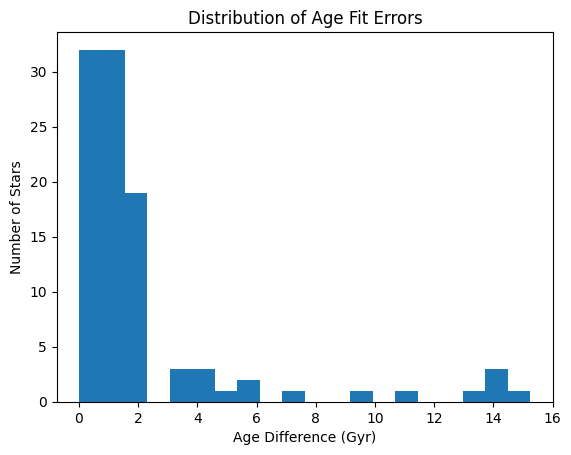

In [29]:
import matplotlib.pyplot as plt

plt.hist(results_df["age_diff"], bins=20)
plt.xlabel("Age Difference (Gyr)")
plt.ylabel("Number of Stars")
plt.title("Distribution of Age Fit Errors")
plt.show()